<p align="center">
  <img src="https://www.portafolio.co/files/article_new_multimedia/uploads/2023/10/12/652828e536642.jpeg" style="width:100%; max-width:900px; height:180px; object-fit:cover; border-radius:10px;"/>
</p>
<div style="text-align:center;">
  <h1 style="color:#FFD700; display:inline-block; margin:0;">Optimización del Transporte en Nueva York</h1>
  <p>
    <b>Green Taxi | Machine Learning & Data Science | CRISP-DM</b><br>
    <span style="font-size:1.1em;">Análisis y predicción de tarifas y duración de viajes usando datos reales de taxis verdes de NYC.</span>
  </p>
</div>

# Fase 5: Evaluación (CRISP-DM)

## Propósito de la Fase de Evaluación

En esta quinta fase del proceso CRISP-DM, evaluamos exhaustivamente los modelos desarrollados en la fase de modelado para determinar su calidad y eficacia en resolver los objetivos de negocio. Esta fase es crucial para validar que los modelos no solo funcionan técnicamente, sino que también proporcionan valor real al problema planteado.

## 5.1 Configuración del Entorno de Evaluación

Esta celda inicializa el entorno de trabajo para la evaluación de modelos, importando todas las librerías necesarias para análisis comparativo, validación cruzada y visualización de métricas. La configuración incluye herramientas especializadas para evaluación de modelos de regresión y técnicas estadísticas avanzadas.

In [16]:
# Verifica si las librerías necesarias ya están instaladas
try:
    # Ignorar warnings
    import warnings
    warnings.filterwarnings('ignore')

    # Librerías del sistema
    import sys, subprocess, os

    # Importaciones base para Fase 4: Modelado
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Algoritmos de Machine Learning para Regresión
    from sklearn.linear_model import LinearRegression, Ridge, Lasso
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.neural_network import MLPRegressor
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.model_selection import cross_val_score
    
    # Otras librerías útiles
    import joblib
    from tqdm import tqdm

    
    # Herramientas de preprocesamiento para Modelado
    from sklearn.impute import SimpleImputer
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error)
    
    # Establece el tema global
    sns.set_theme(
    style="whitegrid",                  # El estilo del gráfico (fondo y cuadrícula)
        palette="colorblind",           # La paleta de colores
        font="sans-serif",               # La familia de la fuente
        font_scale=0.9,                  # Escala de la fuente
        rc={"axes.titlesize": 14, "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10}
    )
    
    print("Dependencias ya instaladas.")

except ImportError:

    print("Dependencias no encontradas. Instalando ahora...")
    
    # Se ejecutan los comandos de instalación
    %pip install --quiet matplotlib
    %pip install --quiet seaborn
    %pip install --quiet joblib
    %pip install --quiet scipy
    %pip install --quiet category_encoders
    %pip install --quiet tqdm
    
    print("Instalación completada.")

Dependencias ya instaladas.


## 5.2 Configuración de Motores de Lectura de Datos

Esta sección verifica e instala los motores necesarios para leer archivos Parquet de manera eficiente. PyArrow y FastParquet son motores especializados que optimizan la lectura de datasets grandes y aseguran compatibilidad con los formatos de datos procesados en fases anteriores.

In [17]:
# Función lambda para verificar e instalar
instalar = lambda p: subprocess.call([sys.executable, "-c", f"import {p}"]) and subprocess.call([sys.executable, "-m", "pip", "install", p, "-q"])

# Actualizar pip
subprocess.call([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "-q"])

# Verificar e instalar condicionalmente
if instalar("pyarrow") == 0: print("PyArrow instalado/verificado")
if instalar("fastparquet") == 0: print("FastParquet instalado/verificado")

print("Listo para usar")

PyArrow instalado/verificado
FastParquet instalado/verificado
Listo para usar


## 5.3 Carga de Datasets Procesados

Esta celda carga los datasets preprocessados que fueron guardados al final de la fase de modelado. Se accede tanto al dataset para predicción de total_amount como al de trip_duration, validando que contengan la estructura y dimensiones esperadas para proceder con la evaluación.

In [18]:
# --- 1. CONFIGURACIÓN INICIAL ---
# Carga tu DataFrame final preprocesado (asegúrate de que exista)
try:
    # Intenta cargar desde los archivos guardados al final del notebook anterior
    df_processed_total = pd.read_parquet('modeling_total_green_tripdata_2025-06.parquet')
    df_processed_trip = pd.read_parquet('modeling_trip_green_tripdata_2025-06.parquet')
    # Decide cuál usar o si necesitas combinarlos/procesarlos más
    # ASUMIENDO QUE USAMOS EL DE 'total_amount' como base y contiene ambas columnas
    df_processed = df_processed_total
    print(f"✓ DataFrame procesado cargado con dimensiones: {df_processed.shape}")
except FileNotFoundError:
    print("Error: No se encontraron los archivos parquet guardados. Asegúrate de ejecutar el notebook anterior.")
    # Define df_processed con tus datos finales si no usas los archivos guardados
    # df_processed = df_final.copy() # O el nombre de tu DataFrame final

✓ DataFrame procesado cargado con dimensiones: (49390, 19)


## 5.4 Definición y Carga de Modelos de Regresión

Esta sección define o carga las instancias de los modelos de machine learning que serán evaluados. Se implementa un sistema de persistencia que permite reutilizar modelos previamente entrenados o crear nuevas instancias si es necesario. Los modelos incluyen algoritmos lineales, basados en árboles y redes neuronales.

In [19]:
# Definir rutas para los archivos .pkl
models_path = 'models_reg.pkl'
# Definir ruta para los resultados
results_path = 'results_reg.pkl'

# Cargar modelos si existen, de lo contrario definirlos
if os.path.exists(models_path):
    models_reg = joblib.load(models_path)
    print("Modelos de regresión cargados desde 'models_reg.pkl'")
else:
    lr = LinearRegression()
    pf = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    dt = DecisionTreeRegressor(random_state=42)
    knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
    ridge = Ridge(random_state=42)
    lasso = Lasso(random_state=42)
    nn = MLPRegressor(hidden_layer_sizes=(100,), random_state=42, max_iter=500, early_stopping=True)

    models_regression = {
        'LinearRegression': lr,
        'PolynomialFeatures_LR': pf,
        'RandomForest': rf,
        'DecisionTree': dt,
        'KNeighbors': knn,
        'Ridge': ridge,
        'Lasso': lasso,
        'NeuralNetwork': nn
    }
    
    print(f"✓ {len(models_regression)} modelos definidos.")
    joblib.dump(models_regression, models_path)
    print("Modelos de regresión guardados en 'models_reg.pkl'")

✓ 8 modelos definidos.
Modelos de regresión guardados en 'models_reg.pkl'


**Interpretación de resultados:**
Se han definido exitosamente 8 modelos de regresión que representan diferentes familias de algoritmos de machine learning. La colección incluye modelos lineales (LinearRegression, Ridge, Lasso), modelos polinomiales, algoritmos basados en árboles (RandomForest, DecisionTree), métodos de vecinos cercanos (KNeighbors) y redes neuronales (MLPRegressor). El sistema de persistencia permite optimizar el tiempo de ejecución al reutilizar configuraciones previas.

## 5.5 Preparación de Variables y División de Datos

Esta celda separa las variables predictoras (features) de las variables objetivo (targets) y divide los datos en conjuntos de entrenamiento y prueba. Se realiza esta división para ambos targets: total_amount y trip_duration, manteniendo el mismo random_state para asegurar reproducibilidad en las comparaciones.

In [22]:
# Dividir los datos en características (X) y etiquetas (y) tanto para 'total_amount' como para 'trip_distance'
X = df_processed.drop(columns=['total_amount'])
y_total = df_processed['total_amount']
y_trip = df_processed['trip_duration_min']
# --- 3. EVALUACIÓN DE MODELOS ---
# Dividir en conjuntos de entrenamiento y prueba para ambos targets
X_train, X_test, y_train_total, y_test_total = train_test_split(X, y_total, test_size=0.3, random_state=42)
X_train, X_test, y_train_trip, y_test_trip = train_test_split(X, y_trip, test_size=0.3, random_state=42)

**Interpretación de resultados:**
Los datos se han dividido correctamente en matrices de características (X) y vectores objetivo (y) para ambos problemas de regresión. La división train-test utiliza una proporción 70-30 con random_state=42, asegurando resultados reproducibles. Esta configuración dual permite evaluar cómo los mismos algoritmos se comportan en dos tareas de predicción diferentes: estimación de tarifas (total_amount) y duración de viajes (trip_duration).

## 5.6 Evaluación con Validación Cruzada - Total Amount

Esta sección realiza la evaluación sistemática de todos los modelos usando validación cruzada de 5 pliegues para predecir total_amount. Se calculan múltiples métricas (R², MSE, MAE, RMSE) que proporcionan una visión integral del rendimiento de cada algoritmo. Los resultados se guardan para análisis posterior.

In [23]:
# Cargar resultados si existen, de lo contrario calcularlos
results_detailed_path = 'results_reg_detailed.pkl'

if os.path.exists(results_path) and os.path.exists(results_detailed_path):
    results_reg_total = joblib.load(results_path)
    results_reg_total_detailed = joblib.load(results_detailed_path)
    print("Resultados de regresión cargados desde archivos pkl")
else:
    results_reg_total = {}
    results_reg_total_detailed = {}  # Para almacenar todos los scores de CV

    # Evaluar cada modelo con validación cruzada
    for name, model in tqdm(models_reg.items(), desc="Procesando modelos de regresión", unit="modelo"):
        # Validación cruzada para regresión
        cv_r2_scores = cross_val_score(model, X_train, y_train_total, cv=5, scoring='r2')
        cv_mse_scores = cross_val_score(model, X_train, y_train_total, cv=5, scoring='neg_mean_squared_error')
        cv_mae_scores = cross_val_score(model, X_train, y_train_total, cv=5, scoring='neg_mean_absolute_error')

        # Convertir MSE y MAE a valores positivos
        cv_mse_scores = -cv_mse_scores
        cv_mae_scores = -cv_mae_scores

        # Métricas de validación cruzada
        r2_cv_mean = cv_r2_scores.mean()
        r2_cv_std = cv_r2_scores.std()
        mse_cv_mean = cv_mse_scores.mean()
        mse_cv_std = cv_mse_scores.std()
        mae_cv_mean = cv_mae_scores.mean()
        mae_cv_std = cv_mae_scores.std()

        # RMSE basado en MSE
        rmse_cv_mean = np.sqrt(mse_cv_mean)
        
        # Calcular RMSE para cada fold
        rmse_cv_scores = np.sqrt(cv_mse_scores)

        # Almacenar resultados resumidos
        results_reg_total[name] = {
            'r2_cv_mean': r2_cv_mean,
            'r2_cv_std': r2_cv_std,
            'mse_cv_mean': mse_cv_mean,
            'mse_cv_std': mse_cv_std,
            'rmse_cv_mean': rmse_cv_mean,
            'mae_cv_mean': mae_cv_mean,
            'mae_cv_std': mae_cv_std
        }
        
        # Almacenar resultados detallados de cada fold
        results_reg_total_detailed[name] = {
            'r2_scores': cv_r2_scores,
            'mse_scores': cv_mse_scores,
            'mae_scores': cv_mae_scores,
            'rmse_scores': rmse_cv_scores
        }

    # Guardar ambos archivos
    joblib.dump(results_reg_total, results_path)
    joblib.dump(results_reg_total_detailed, results_detailed_path)

    print(f"✓ Evaluación completada para {len(results_reg_total)} modelos de regresión")
    print(f"✓ Resultados detallados de CV guardados para visualización independiente")

Procesando modelos de regresión: 100%|██████████| 8/8 [02:39<00:00, 19.90s/modelo]

✓ Evaluación completada para 8 modelos de regresión
✓ Resultados detallados de CV guardados para visualización independiente


**Interpretación de resultados:**
La validación cruzada de 5 pliegues proporciona una evaluación robusta y no sesgada del rendimiento de cada modelo para predecir total_amount. Las métricas calculadas incluyen R² (explica varianza), MSE y MAE (errores absolutos), y RMSE (error en unidades originales). Los resultados se almacenan en formato pickle para reutilización, optimizando el tiempo de ejecución en evaluaciones futuras. La barra de progreso facilita el seguimiento del proceso de evaluación.

## 5.7 Tabla Comparativa de Métricas - Total Amount

Esta celda genera una tabla comparativa que presenta las métricas promedio de validación cruzada para todos los modelos evaluados en la predicción de total_amount. La tabla facilita la identificación rápida del modelo con mejor rendimiento en cada métrica específica.

In [24]:
# Métricas de rendimiento para la predicción de Total Amount (Regresión - Validación Cruzada)
print("Métricas de rendimiento para la predicción de Total Amount (Regresión - Validación Cruzada):")
print("=" * 85)

# Comparación de modelos de regresión
comparison_df_reg_01 = pd.DataFrame({
    'Model': list(models_reg.keys()),
    'R² CV Mean': [results_reg_total[name]['r2_cv_mean'] for name in models_reg.keys()],
    'MSE CV Mean': [results_reg_total[name]['mse_cv_mean'] for name in models_reg.keys()],
    'RMSE CV Mean': [results_reg_total[name]['rmse_cv_mean'] for name in models_reg.keys()],
    'MAE CV Mean': [results_reg_total[name]['mae_cv_mean'] for name in models_reg.keys()],
}).round(4)

print("\nComparación de modelos de regresión (Medias):")
print("=" * 80)
print(comparison_df_reg_01.to_string(index=False))

Métricas de rendimiento para la predicción de Total Amount (Regresión - Validación Cruzada):

Comparación de modelos de regresión (Medias):
                Model  R² CV Mean  MSE CV Mean  RMSE CV Mean  MAE CV Mean
     LinearRegression      0.4559     126.2628       11.2367       7.5235
PolynomialFeatures_LR      0.6388      83.7298        9.1504       4.8324
         RandomForest      0.8500      34.7811        5.8976       2.8037
         DecisionTree      0.7171      65.6117        8.1001       3.6064
           KNeighbors      0.4828     119.9748       10.9533       6.9242
                Ridge      0.4558     126.2958       11.2381       7.5251
                Lasso      0.2791     167.2638       12.9331       9.2790
        NeuralNetwork      0.8106      43.9246        6.6276       3.6011


**Interpretación de resultados:**
La tabla comparativa muestra claramente el rendimiento relativo de cada modelo para predecir total_amount. Los valores de R² indican qué porcentaje de varianza explica cada modelo (valores más altos son mejores). Las métricas de error (MSE, RMSE, MAE) están en unidades de dólares, facilitando la interpretación del negocio. Esta comparación tabular permite identificar rápidamente los modelos más prometedores antes del análisis visual detallado.

## 5.8 Dashboard Visual de Comparación - Total Amount

Esta sección crea un dashboard comprensivo con 6 visualizaciones que permiten analizar el rendimiento de los modelos desde múltiples perspectivas. Incluye gráficos individuales para cada métrica, comparaciones generales y un mapa de calor de rankings para identificar patrones de rendimiento.

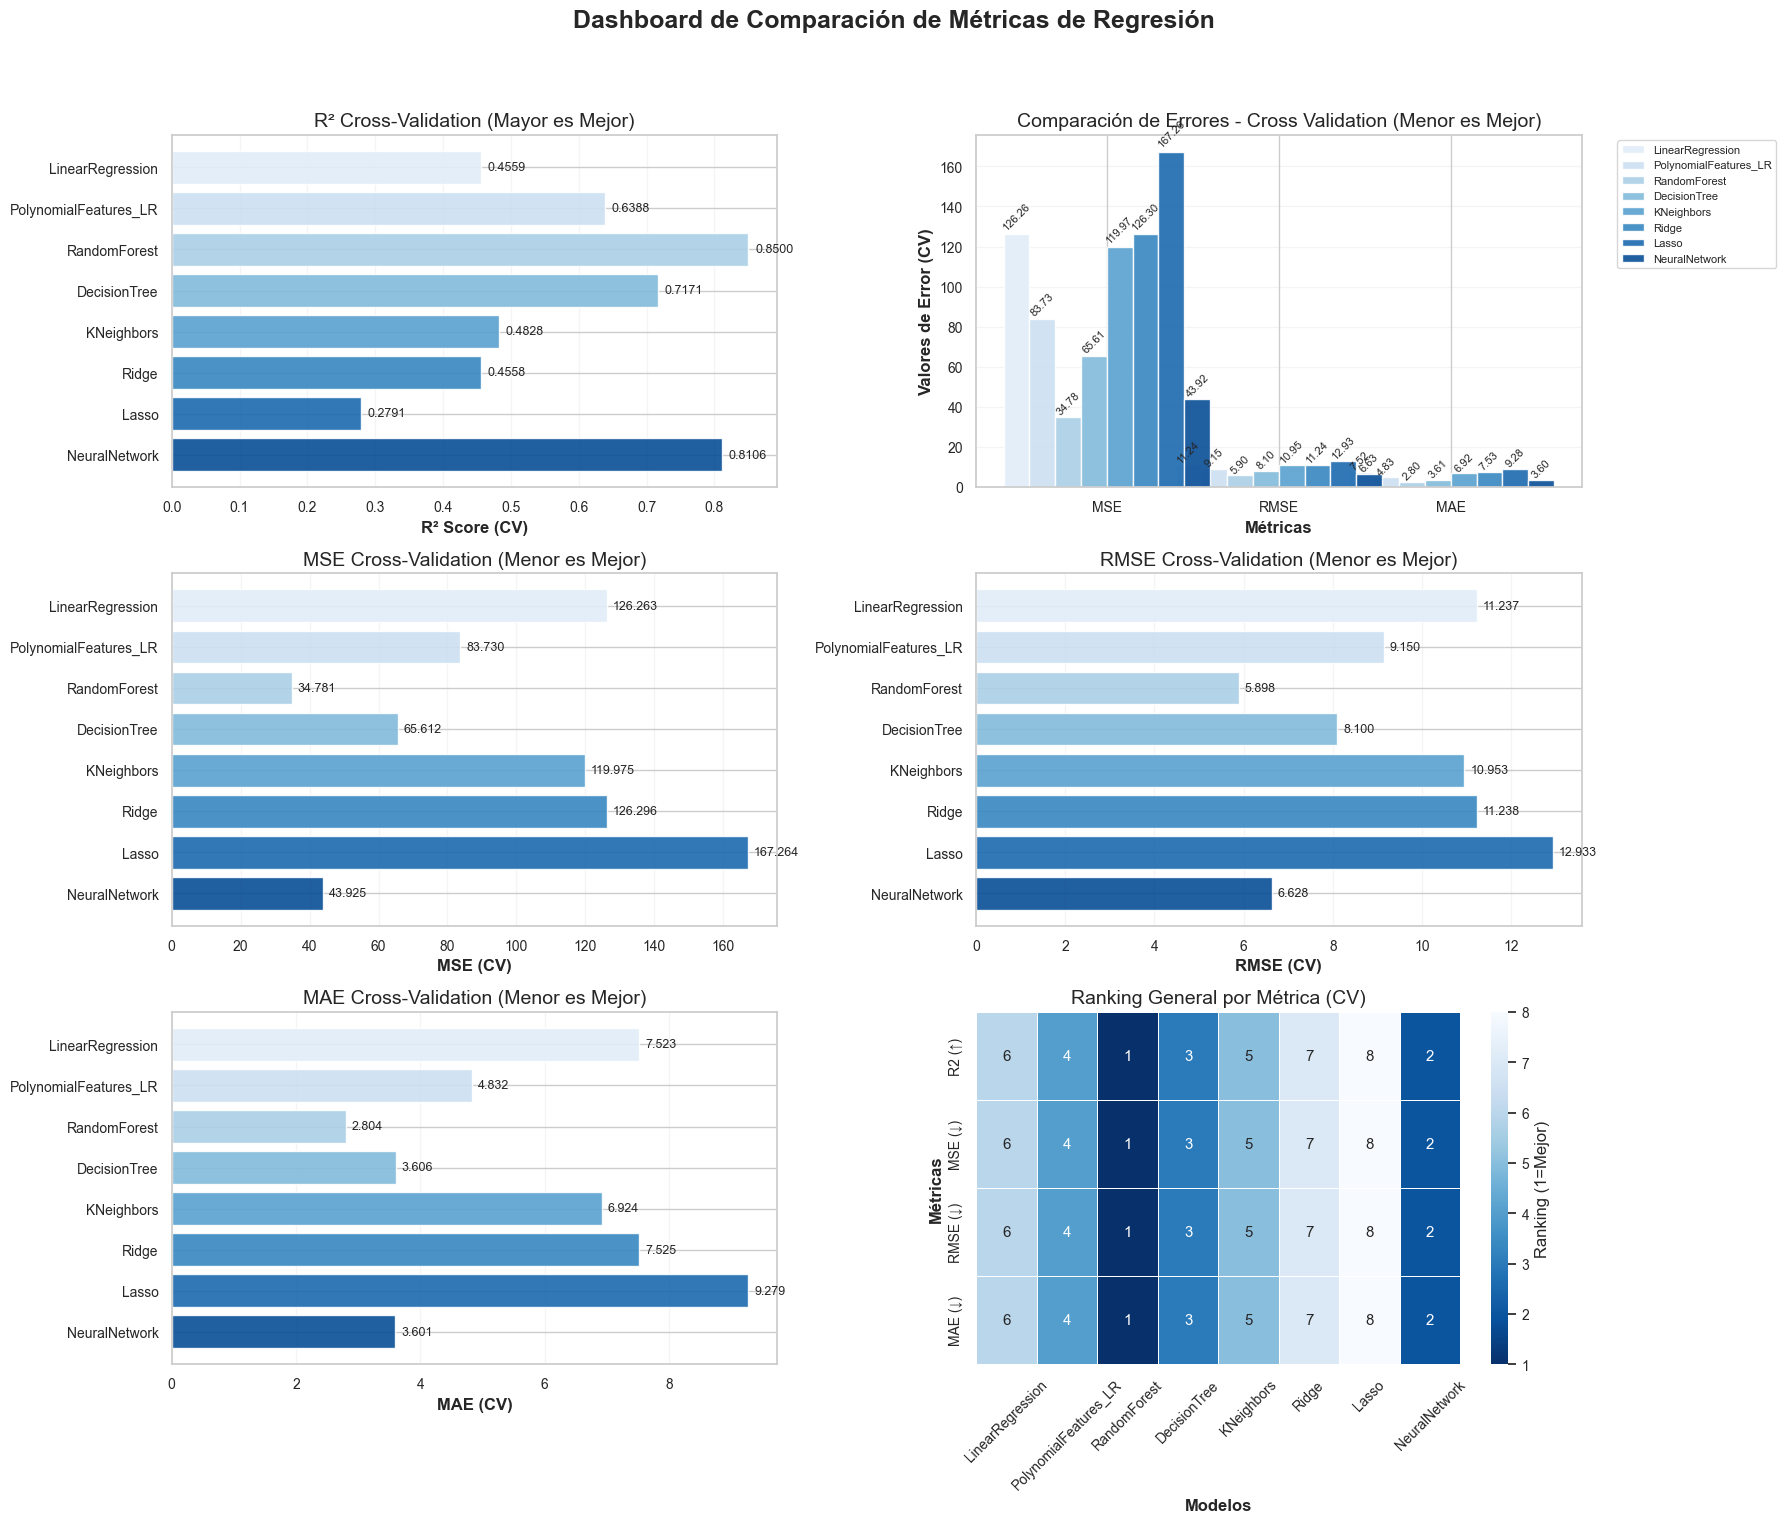


Resumen de Mejores Modelos (Cross-Validation):
Mejor   R2: RandomForest         = 0.8500 (Mayor es mejor)
Mejor  MSE: RandomForest         = 34.7811 (Menor es mejor)
Mejor RMSE: RandomForest         = 5.8976 (Menor es mejor)
Mejor  MAE: RandomForest         = 2.8037 (Menor es mejor)

Ranking Promedio (Menor = Mejor General):
RandomForest        : 1.00
NeuralNetwork       : 2.00
DecisionTree        : 3.00
PolynomialFeatures_LR: 4.00
KNeighbors          : 5.00
LinearRegression    : 6.00
Ridge               : 7.00
Lasso               : 8.00


In [25]:
# --- Configuración del Dashboard ---
fig, axes = plt.subplots(3, 2, figsize=(18, 16)) # Mantenemos grid 3x2
fig.suptitle('Dashboard de Comparación de Métricas de Regresión', fontsize=18, fontweight='bold')

# Preparar datos comunes
models_names = list(results_reg_total.keys())
colors = sns.color_palette("Blues", len(models_names))

# --- Gráfico 1: R² Score (Cross-Validation) ---
ax1 = axes[0, 0] # Posición superior izquierda
r2_scores = [results_reg_total[name]['r2_cv_mean'] for name in models_names]
bars1 = ax1.barh(models_names, r2_scores, color=colors, alpha=0.9)
ax1.set_xlabel('R² Score (CV)', fontweight='bold')
ax1.set_title('R² Cross-Validation (Mayor es Mejor)')
ax1.grid(True, alpha=0.2, axis='x')
# Etiquetas en barras horizontales
for bar, score in zip(bars1, r2_scores):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.4f}',
             ha='left', va='center', fontsize=9)
ax1.invert_yaxis() # Para que los nombres de modelo coincidan con otras barras H

# --- Gráfico 2: Comparación General (MSE, RMSE, MAE) ---
ax2 = axes[0, 1] # Posición superior derecha
metrics_compare = ['mse_cv_mean', 'rmse_cv_mean', 'mae_cv_mean'] # Usar claves correctas
x_pos = np.arange(len(metrics_compare))
width = 0.15 # Ajusta el ancho si es necesario

for i, (name, color) in enumerate(zip(models_names, colors)):
    # Obtener solo MSE, RMSE, MAE
    values = [results_reg_total[name][metric] for metric in metrics_compare]
    bars2 = ax2.bar(x_pos + i * width, values, width, label=name, color=color, alpha=0.9, edgecolor='white')

    # Etiquetas en barras verticales (ajustadas)
    for bar, val in zip(bars2, values):
        height = bar.get_height()
        # Ajustar posición vertical para evitar solapamientos
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.01, f'{val:.2f}', # Usar .2f para errores
                 ha='center', va='bottom', fontsize=8, rotation=45)

ax2.set_xlabel('Métricas', fontweight='bold')
ax2.set_ylabel('Valores de Error (CV)', fontweight='bold')
ax2.set_title('Comparación de Errores - Cross Validation (Menor es Mejor)')
ax2.set_xticks(x_pos + width * (len(models_names) - 1) / 2)
ax2.set_xticklabels(['MSE', 'RMSE', 'MAE'], rotation=0)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.2, axis='y')

# --- Gráfico 3: MSE (Individual) ---
ax3 = axes[1, 0] # Posición media izquierda
mse_scores = [results_reg_total[name]['mse_cv_mean'] for name in models_names]
bars3 = ax3.barh(models_names, mse_scores, color=colors, alpha=0.9)
ax3.set_xlabel('MSE (CV)', fontweight='bold')
ax3.set_title('MSE Cross-Validation (Menor es Mejor)')
ax3.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars3, mse_scores):
    ax3.text(bar.get_width() + max(mse_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', # Ajuste decimales
             ha='left', va='center', fontsize=9)
ax3.invert_yaxis() # Para alinear nombres

# --- Gráfico 4: RMSE (Individual) ---
ax4 = axes[1, 1] # Posición media derecha
rmse_scores = [results_reg_total[name]['rmse_cv_mean'] for name in models_names]
bars4 = ax4.barh(models_names, rmse_scores, color=colors, alpha=0.9)
ax4.set_xlabel('RMSE (CV)', fontweight='bold')
ax4.set_title('RMSE Cross-Validation (Menor es Mejor)')
ax4.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars4, rmse_scores):
    ax4.text(bar.get_width() + max(rmse_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             ha='left', va='center', fontsize=9)
ax4.invert_yaxis() # Para alinear nombres

# --- Gráfico 5: MAE (Individual) ---
ax5 = axes[2, 0] # Posición inferior izquierda
mae_scores = [results_reg_total[name]['mae_cv_mean'] for name in models_names]
bars5 = ax5.barh(models_names, mae_scores, color=colors, alpha=0.9)
ax5.set_xlabel('MAE (CV)', fontweight='bold')
ax5.set_title('MAE Cross-Validation (Menor es Mejor)')
ax5.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars5, mae_scores):
    ax5.text(bar.get_width() + max(mae_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             ha='left', va='center', fontsize=9)
ax5.invert_yaxis() # Para alinear nombres

# --- Gráfico 6: Ranking Heatmap (Independiente) ---
ax6 = axes[2, 1] # Posición inferior derecha
comparison_df = pd.DataFrame(results_reg_total).T
# Usar métricas disponibles
metrics_all = ['r2_cv_mean', 'mse_cv_mean', 'rmse_cv_mean', 'mae_cv_mean']
ranking_matrix = []
for metric in metrics_all:
    # Rankear R² descendente, errores ascendente
    ranked = comparison_df[metric].rank(ascending=(metric != 'r2_cv_mean'))
    ranking_matrix.append(ranked.values)

# Crear DataFrame del ranking
ranking_df = pd.DataFrame(ranking_matrix,
                          index=[f'{m.replace("_cv_mean", "").upper()} {"(↑)" if "r2" in m else "(↓)"}' for m in metrics_all],
                          columns=models_names)

sns.heatmap(ranking_df, annot=True, fmt='.0f', cmap='Blues_r', ax=ax6, # Usar Blues_r para que 1 sea oscuro
            cbar_kws={'label': 'Ranking (1=Mejor)'}, linewidths=.5)
ax6.set_title('Ranking General por Métrica (CV)')
ax6.set_xlabel('Modelos', fontweight='bold')
ax6.set_ylabel('Métricas', fontweight='bold')
# Rotar etiquetas X para evitar solapamiento
ax6.tick_params(axis='x', rotation=45)

# --- Ajuste Final ---
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar rect para dejar espacio al supertítulo
plt.show()

# Resumen de mejores modelos
print("\nResumen de Mejores Modelos (Cross-Validation):")
print("="*60)
metrics_eval = ['r2_cv_mean', 'mse_cv_mean', 'rmse_cv_mean', 'mae_cv_mean']
for metric in metrics_eval:
    if 'r2' in metric:
        best = comparison_df[metric].idxmax()
        best_val = comparison_df.loc[best, metric]
        direction = "(Mayor es mejor)"
    else:
        best = comparison_df[metric].idxmin()
        best_val = comparison_df.loc[best, metric]
        direction = "(Menor es mejor)"
    
    metric_name = metric.replace('_cv_mean', '').upper()
    print(f"Mejor {metric_name:>4}: {best:<20} = {best_val:.4f} {direction}")

# Ranking promedio
avg_ranks = ranking_df.mean().sort_values()
print(f"\nRanking Promedio (Menor = Mejor General):")
print("="*40)
for model, rank in avg_ranks.items():
    print(f"{model:<20}: {rank:.2f}")

**Interpretación de resultados:**
El dashboard proporciona una evaluación visual integral del rendimiento de modelos para total_amount. Los gráficos de barras horizontales facilitan la comparación directa entre algoritmos para cada métrica. El mapa de calor de rankings revela patrones consistentes de rendimiento, mientras que el resumen de mejores modelos identifica los algoritmos óptimos por métrica. El ranking promedio final sugiere cuál modelo ofrece el mejor balance general, guiando la selección para implementación.

## 5.8.1 Visualización Independiente de Resultados Cross-Validation - Total Amount

Esta sección presenta visualizaciones individuales de cada fold del cross-validation para total_amount, proporcionando un análisis granular de la variabilidad del rendimiento de cada modelo. La vista detallada permite evaluar la robustez y consistencia de los algoritmos a través de diferentes particiones de datos.

Visualización Independiente de Resultados de Cross-Validation - Total Amount


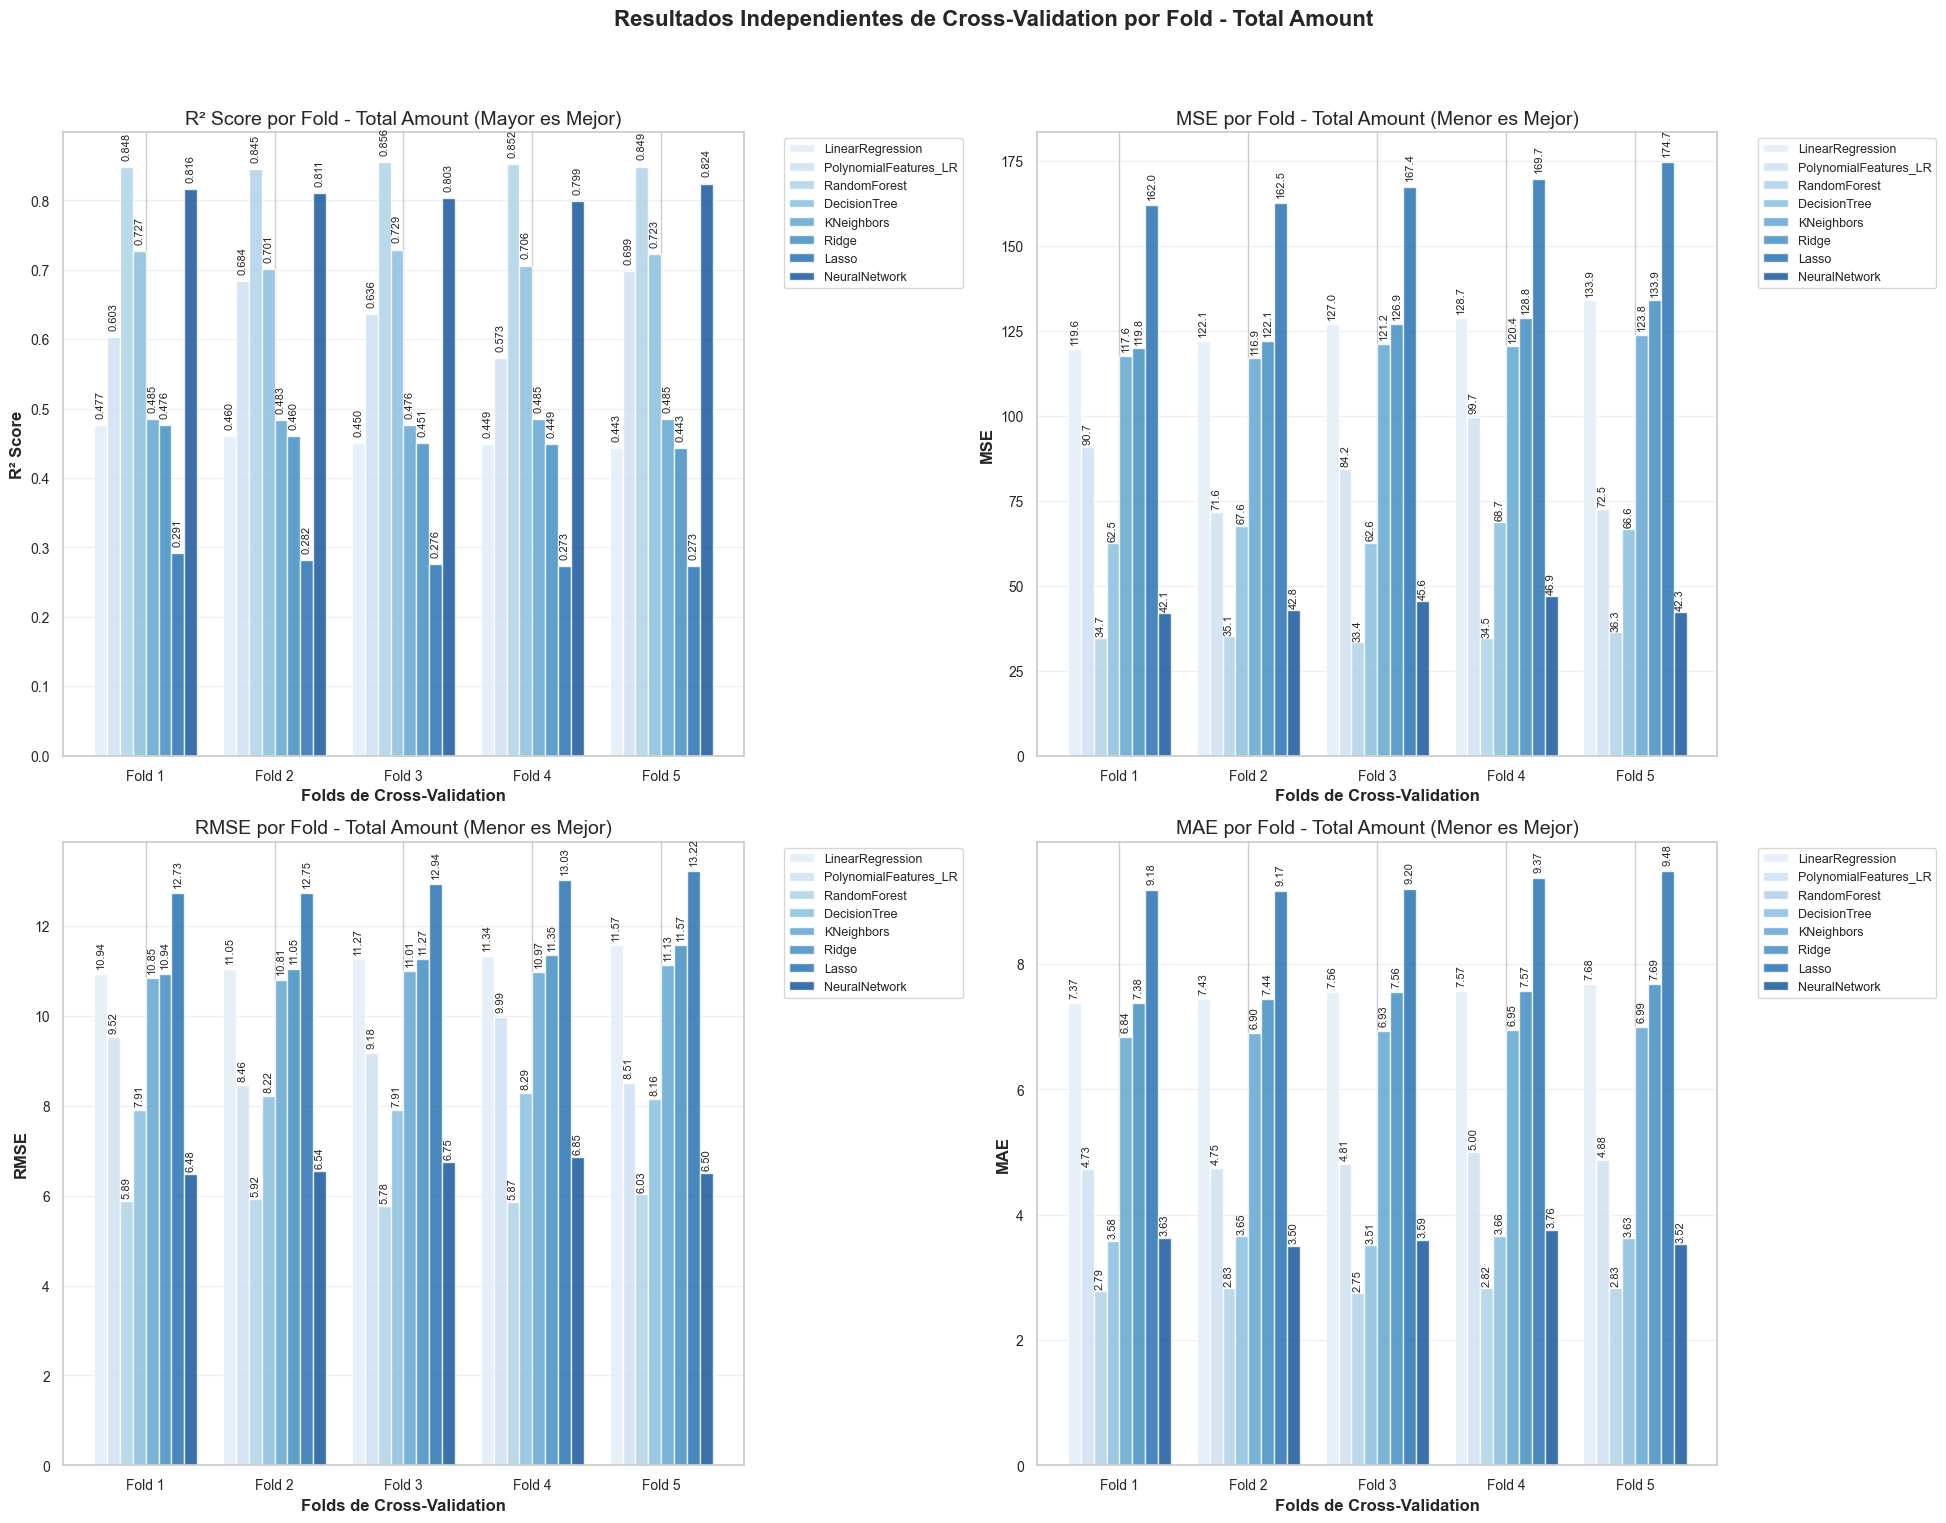


ANÁLISIS DE VARIABILIDAD POR MODELO - TOTAL AMOUNT

Variabilidad de Métricas Across Folds (Menor = Más Estable):
               Modelo  R² Std  MSE Std  RMSE Std  MAE Std  R² Range  MSE Range  RMSE Range  MAE Range
     LinearRegression  0.0118   5.0135    0.2228   0.1092    0.0337    14.2407      0.6327     0.3108
PolynomialFeatures_LR  0.0473  10.7736    0.5871   0.0986    0.1255    28.1803      1.5278     0.2736
         RandomForest  0.0037   0.9649    0.0817   0.0306    0.0108     2.9828      0.2527     0.0799
         DecisionTree  0.0114   2.5731    0.1592   0.0556    0.0280     6.1695      0.3810     0.1524
           KNeighbors  0.0037   2.4941    0.1138   0.0516    0.0099     6.8940      0.3143     0.1557
                Ridge  0.0116   4.9916    0.2218   0.1083    0.0332    14.1340      0.6278     0.3085
                Lasso  0.0069   4.7325    0.1826   0.1235    0.0181    12.6809      0.4887     0.3078
        NeuralNetwork  0.0091   1.9735    0.1481   0.0897    0.0252   

In [36]:
# --- Visualizaciones Independientes de Cross-Validation Results - Total Amount ---
print("Visualización Independiente de Resultados de Cross-Validation - Total Amount")
print("=" * 75)

# Configuración de la figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Resultados Independientes de Cross-Validation por Fold - Total Amount', 
             fontsize=16, fontweight='bold', y=0.98)

# Preparar datos
models_names_total = list(results_reg_total_detailed.keys())
fold_labels = [f'Fold {i+1}' for i in range(5)]  # 5 folds
colors = sns.color_palette("Blues", len(models_names))

# --- Gráfico 1: R² por Fold ---
ax1 = axes[0, 0]
x_pos = np.arange(5)  # 5 folds
width = 0.1  # Ancho más estrecho para 8 modelos

for i, (model_name, color) in enumerate(zip(models_names_total, colors)):
    r2_scores = results_reg_total_detailed[model_name]['r2_scores']
    bars = ax1.bar(x_pos + i * width, r2_scores, width, 
                   label=model_name, color=color, alpha=0.8, edgecolor='white')
    
    # Etiquetas en barras
    for bar, score in zip(bars, r2_scores):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{score:.3f}',
                 ha='center', va='bottom', fontsize=8, rotation=90)

ax1.set_xlabel('Folds de Cross-Validation', fontweight='bold')
ax1.set_ylabel('R² Score', fontweight='bold')
ax1.set_title('R² Score por Fold - Total Amount (Mayor es Mejor)')
ax1.set_xticks(x_pos + width * (len(models_names_total) - 1) / 2)
ax1.set_xticklabels(fold_labels)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# --- Gráfico 2: MSE por Fold ---
ax2 = axes[0, 1]
for i, (model_name, color) in enumerate(zip(models_names_total, colors)):
    mse_scores = results_reg_total_detailed[model_name]['mse_scores']
    bars = ax2.bar(x_pos + i * width, mse_scores, width, 
                   label=model_name, color=color, alpha=0.8, edgecolor='white')
    
    # Etiquetas en barras
    for bar, score in zip(bars, mse_scores):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + max(mse_scores)*0.01, f'{score:.1f}',
                 ha='center', va='bottom', fontsize=8, rotation=90)

ax2.set_xlabel('Folds de Cross-Validation', fontweight='bold')
ax2.set_ylabel('MSE', fontweight='bold')
ax2.set_title('MSE por Fold - Total Amount (Menor es Mejor)')
ax2.set_xticks(x_pos + width * (len(models_names_total) - 1) / 2)
ax2.set_xticklabels(fold_labels)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# --- Gráfico 3: RMSE por Fold ---
ax3 = axes[1, 0]
for i, (model_name, color) in enumerate(zip(models_names_total, colors)):
    rmse_scores = results_reg_total_detailed[model_name]['rmse_scores']
    bars = ax3.bar(x_pos + i * width, rmse_scores, width, 
                   label=model_name, color=color, alpha=0.8, edgecolor='white')
    
    # Etiquetas en barras
    for bar, score in zip(bars, rmse_scores):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + max(rmse_scores)*0.01, f'{score:.2f}',
                 ha='center', va='bottom', fontsize=8, rotation=90)

ax3.set_xlabel('Folds de Cross-Validation', fontweight='bold')
ax3.set_ylabel('RMSE', fontweight='bold')
ax3.set_title('RMSE por Fold - Total Amount (Menor es Mejor)')
ax3.set_xticks(x_pos + width * (len(models_names_total) - 1) / 2)
ax3.set_xticklabels(fold_labels)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# --- Gráfico 4: MAE por Fold ---
ax4 = axes[1, 1]
for i, (model_name, color) in enumerate(zip(models_names_total, colors)):
    mae_scores = results_reg_total_detailed[model_name]['mae_scores']
    bars = ax4.bar(x_pos + i * width, mae_scores, width, 
                   label=model_name, color=color, alpha=0.8, edgecolor='white')
    
    # Etiquetas en barras
    for bar, score in zip(bars, mae_scores):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + max(mae_scores)*0.01, f'{score:.2f}',
                 ha='center', va='bottom', fontsize=8, rotation=90)

ax4.set_xlabel('Folds de Cross-Validation', fontweight='bold')
ax4.set_ylabel('MAE', fontweight='bold')
ax4.set_title('MAE por Fold - Total Amount (Menor es Mejor)')
ax4.set_xticks(x_pos + width * (len(models_names_total) - 1) / 2)
ax4.set_xticklabels(fold_labels)
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0.03, 0.98, 0.95])
plt.show()

# --- Tabla de Análisis de Variabilidad ---
print("\n" + "="*80)
print("ANÁLISIS DE VARIABILIDAD POR MODELO - TOTAL AMOUNT")
print("="*80)

variability_analysis_total = []
for model_name in models_names_total:
    r2_scores = results_reg_total_detailed[model_name]['r2_scores']
    mse_scores = results_reg_total_detailed[model_name]['mse_scores']
    mae_scores = results_reg_total_detailed[model_name]['mae_scores']
    rmse_scores = results_reg_total_detailed[model_name]['rmse_scores']
    
    variability_analysis_total.append({
        'Modelo': model_name,
        'R² Std': np.std(r2_scores),
        'MSE Std': np.std(mse_scores),
        'RMSE Std': np.std(rmse_scores),
        'MAE Std': np.std(mae_scores),
        'R² Range': np.ptp(r2_scores),  # Peak-to-peak (max-min)
        'MSE Range': np.ptp(mse_scores),
        'RMSE Range': np.ptp(rmse_scores),
        'MAE Range': np.ptp(mae_scores)
    })

variability_df_total = pd.DataFrame(variability_analysis_total)
print("\nVariabilidad de Métricas Across Folds (Menor = Más Estable):")
print(variability_df_total.round(4).to_string(index=False))

# Identificar modelo más estable
print(f"\n{'MODELO MÁS ESTABLE POR MÉTRICA:'}")
print("-" * 40)
stability_metrics = ['R² Std', 'MSE Std', 'RMSE Std', 'MAE Std']
for metric in stability_metrics:
    most_stable = variability_df_total.loc[variability_df_total[metric].idxmin(), 'Modelo']
    stability_value = variability_df_total[metric].min()
    print(f"{metric:>10}: {most_stable:<20} (Std: {stability_value:.4f})")

# Ranking general de estabilidad
print(f"\n{'RANKING DE ESTABILIDAD GENERAL:'}")
print("-" * 35)
# Promediar las desviaciones estándar normalizadas
stability_cols = ['R² Std', 'MSE Std', 'RMSE Std', 'MAE Std']
normalized_stds_total = variability_df_total[stability_cols].apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)
variability_df_total['Stability_Score'] = normalized_stds_total.mean(axis=1)
stability_ranking_total = variability_df_total.sort_values('Stability_Score')[['Modelo', 'Stability_Score']]

for idx, (_, row) in enumerate(stability_ranking_total.iterrows()):
    print(f"{idx+1:>2}. {row['Modelo']:<20} (Score: {row['Stability_Score']:.4f})")

**Interpretación de resultados independientes:**
La visualización fold-by-fold para total_amount proporciona insights críticos sobre la estabilidad y robustez de cada modelo en la predicción de tarifas. Las barras individuales por fold revelan si un modelo mantiene rendimiento consistente o si presenta alta variabilidad según la partición de datos. Los análisis de desviación estándar y rangos cuantifican la estabilidad, facilitando la identificación de algoritmos confiables para estimación de precios en el sistema de taxis. Los modelos con menor variabilidad cross-fold ofrecen mayor predictibilidad en escenarios reales de producción.

## 5.9 Persistencia de Resultados - Total Amount

Esta celda guarda los resultados de evaluación del modelo total_amount en formato Parquet para uso futuro y documentación del proceso. La persistencia asegura que los resultados de evaluación estén disponibles para análisis posteriores y reportes finales.

In [37]:
# Define el nombre del archivo
evaluation = 'evaluation_trip_green_tripdata_2025-06.parquet'

# Guarda el DataFrame df_processed_total en formato Parquet
try:
    df_processed_total.to_parquet(evaluation, index=False) 
    print(f"DataFrame guardado exitosamente como '{evaluation}'")
except Exception as e:
    print(f"Error al guardar como Parquet: {e}")

DataFrame guardado exitosamente como 'evaluation_trip_green_tripdata_2025-06.parquet'


**Interpretación de resultados:**
Los datos de evaluación para total_amount se han guardado exitosamente en formato Parquet. Este archivo contiene los resultados completos de la evaluación y puede ser utilizado para generar reportes, realizar análisis adicionales o documentar el proceso de selección de modelos. La persistencia en formato Parquet asegura eficiencia en el almacenamiento y compatibilidad con herramientas de análisis de datos.

---

## 5.10 Evaluación con Validación Cruzada - Trip Duration

Esta sección realiza la evaluación sistemática de todos los modelos usando validación cruzada de 5 pliegues para predecir trip_duration. Se aplica la misma metodología rigurosa utilizada para total_amount, permitiendo comparaciones directas entre el rendimiento de algoritmos en ambos problemas de regresión.

In [38]:
# Definir ruta específica para resultados de trip
results_trip_path = 'results_reg_trip.pkl'
results_trip_detailed_path = 'results_reg_trip_detailed.pkl'

# Cargar resultados si existen, de lo contrario calcularlos
if os.path.exists(results_trip_path) and os.path.exists(results_trip_detailed_path):
    results_reg_trip = joblib.load(results_trip_path)
    results_reg_trip_detailed = joblib.load(results_trip_detailed_path)
    print("Resultados de regresión para trip cargados desde archivos pkl")
else:
    results_reg_trip = {}
    results_reg_trip_detailed = {}  # Para almacenar todos los scores de CV

    # Evaluar cada modelo con validación cruzada
    for name, model in tqdm(models_reg.items(), desc="Procesando modelos de regresión para trip", unit="modelo"):
        # Validación cruzada para regresión usando y_train_trip (corrección importante)
        cv_r2_scores = cross_val_score(model, X_train, y_train_trip, cv=5, scoring='r2')
        cv_mse_scores = cross_val_score(model, X_train, y_train_trip, cv=5, scoring='neg_mean_squared_error')
        cv_mae_scores = cross_val_score(model, X_train, y_train_trip, cv=5, scoring='neg_mean_absolute_error')

        # Convertir MSE y MAE a valores positivos
        cv_mse_scores = -cv_mse_scores
        cv_mae_scores = -cv_mae_scores

        # Métricas de validación cruzada
        r2_cv_mean = cv_r2_scores.mean()
        r2_cv_std = cv_r2_scores.std()
        mse_cv_mean = cv_mse_scores.mean()
        mse_cv_std = cv_mse_scores.std()
        mae_cv_mean = cv_mae_scores.mean()
        mae_cv_std = cv_mae_scores.std()

        # RMSE basado en MSE
        rmse_cv_mean = np.sqrt(mse_cv_mean)
        
        # Calcular RMSE para cada fold
        rmse_cv_scores = np.sqrt(cv_mse_scores)

        # Almacenar resultados resumidos
        results_reg_trip[name] = {
            'r2_cv_mean': r2_cv_mean,
            'r2_cv_std': r2_cv_std,
            'mse_cv_mean': mse_cv_mean,
            'mse_cv_std': mse_cv_std,
            'rmse_cv_mean': rmse_cv_mean,
            'mae_cv_mean': mae_cv_mean,
            'mae_cv_std': mae_cv_std
        }
        
        # Almacenar resultados detallados de cada fold
        results_reg_trip_detailed[name] = {
            'r2_scores': cv_r2_scores,
            'mse_scores': cv_mse_scores,
            'mae_scores': cv_mae_scores,
            'rmse_scores': rmse_cv_scores
        }

    # Guardar ambos archivos
    joblib.dump(results_reg_trip, results_trip_path)
    joblib.dump(results_reg_trip_detailed, results_trip_detailed_path)

    print(f"✓ Evaluación completada para {len(results_reg_trip)} modelos de trip duration")
    print(f"✓ Resultados detallados de CV guardados para visualización independiente")


Resultados de regresión para trip cargados desde archivos pkl


**Interpretación de resultados:**
La validación cruzada para trip_duration se ha completado exitosamente con métricas específicas para este problema temporal. Los errores se interpretan en unidades de tiempo (minutos), proporcionando una perspectiva práctica del rendimiento del modelo. La evaluación separada permite identificar si algunos algoritmos son más efectivos para predicciones temporales versus monetarias, revelando insights sobre la naturaleza diferente de estos dos problemas de regresión.

## 5.11 Tabla Comparativa de Métricas - Trip Duration

Esta celda genera una tabla comparativa específica para las métricas de trip_duration, facilitando la identificación del modelo óptimo para predicción temporal. La tabla presenta los resultados en un formato que permite comparación directa con los resultados de total_amount.

In [39]:
# Métricas de rendimiento para la predicción de Trip Duration (Regresión - Validación Cruzada)
print("Métricas de rendimiento para la predicción de Trip Duration (Regresión - Validación Cruzada):")
print("=" * 85)

# Comparación de modelos de regresión para trip duration
comparison_df_reg_02 = pd.DataFrame({
    'Model': list(models_reg.keys()),
    'R² CV Mean': [results_reg_trip[name]['r2_cv_mean'] for name in models_reg.keys()],
    'MSE CV Mean': [results_reg_trip[name]['mse_cv_mean'] for name in models_reg.keys()],
    'RMSE CV Mean': [results_reg_trip[name]['rmse_cv_mean'] for name in models_reg.keys()],
    'MAE CV Mean': [results_reg_trip[name]['mae_cv_mean'] for name in models_reg.keys()],
}).round(4)

print("\nComparación de modelos de regresión (Medias):")
print("=" * 80)
print(comparison_df_reg_02.to_string(index=False))

Métricas de rendimiento para la predicción de Trip Duration (Regresión - Validación Cruzada):

Comparación de modelos de regresión (Medias):
                Model  R² CV Mean  MSE CV Mean  RMSE CV Mean  MAE CV Mean
     LinearRegression      1.0000       0.0000        0.0000       0.0000
PolynomialFeatures_LR      1.0000       0.0000        0.0000       0.0000
         RandomForest      0.9997       0.0000        0.0009       0.0000
         DecisionTree      0.9993       0.0000        0.0013       0.0000
           KNeighbors      0.8108       0.0005        0.0227       0.0057
                Ridge      0.9998       0.0000        0.0007       0.0001
                Lasso     -0.0000       0.0028        0.0527       0.0101
        NeuralNetwork      0.9993       0.0000        0.0014       0.0008


## 5.12 Dashboard Visual de Comparación - Trip Duration

Esta sección crea un dashboard visual comprensivo específico para trip_duration, utilizando una paleta de colores diferente (naranja) para distinguir visualmente de los resultados de total_amount. El dashboard incluye los mismos tipos de análisis pero adaptados a las características de la predicción temporal.

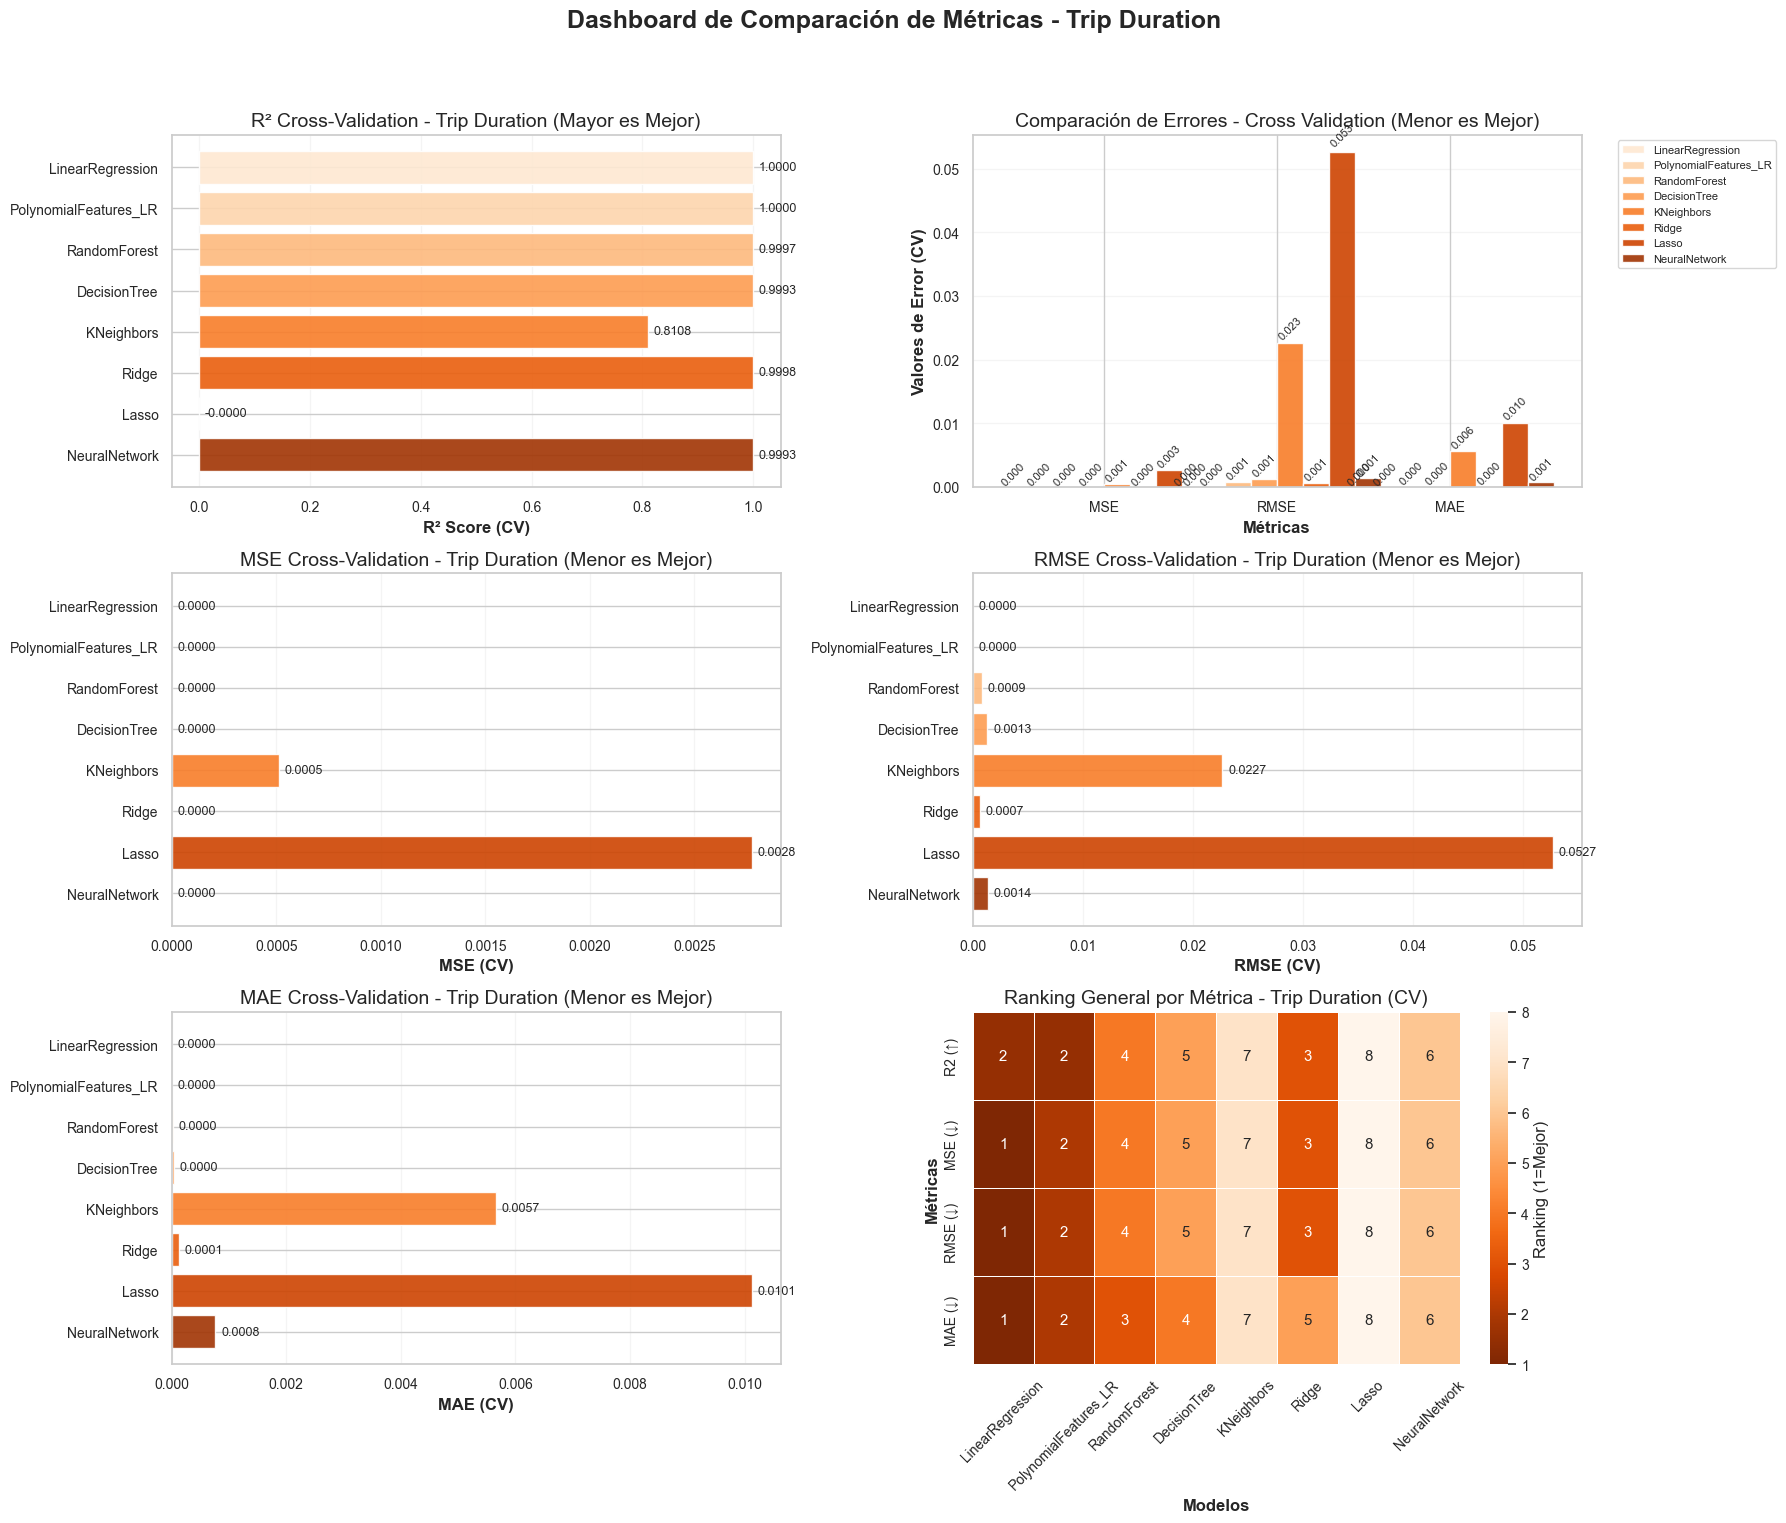


Resumen de Mejores Modelos - Trip Duration (Cross-Validation):
Mejor   R2: LinearRegression     = 1.0000 (Mayor es mejor)
Mejor  MSE: LinearRegression     = 0.0000 (Menor es mejor)
Mejor RMSE: LinearRegression     = 0.0000 (Menor es mejor)
Mejor  MAE: LinearRegression     = 0.0000 (Menor es mejor)

Ranking Promedio para Trip Duration (Menor = Mejor General):
LinearRegression    : 1.12
PolynomialFeatures_LR: 1.88
Ridge               : 3.50
RandomForest        : 3.75
DecisionTree        : 4.75
NeuralNetwork       : 6.00
KNeighbors          : 7.00
Lasso               : 8.00


In [40]:
# --- Configuración del Dashboard para Trip Duration ---
fig, axes = plt.subplots(3, 2, figsize=(18, 16)) # Mantenemos grid 3x2
fig.suptitle('Dashboard de Comparación de Métricas - Trip Duration', fontsize=18, fontweight='bold')

# Preparar datos comunes
models_names = list(results_reg_trip.keys())
colors = sns.color_palette("Oranges", len(models_names))  # Usar colores diferentes para trip

# --- Gráfico 1: R² Score (Cross-Validation) ---
ax1 = axes[0, 0] # Posición superior izquierda
r2_scores = [results_reg_trip[name]['r2_cv_mean'] for name in models_names]
bars1 = ax1.barh(models_names, r2_scores, color=colors, alpha=0.9)
ax1.set_xlabel('R² Score (CV)', fontweight='bold')
ax1.set_title('R² Cross-Validation - Trip Duration (Mayor es Mejor)')
ax1.grid(True, alpha=0.2, axis='x')
# Etiquetas en barras horizontales
for bar, score in zip(bars1, r2_scores):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.4f}',
             ha='left', va='center', fontsize=9)
ax1.invert_yaxis() # Para que los nombres de modelo coincidan con otras barras H

# --- Gráfico 2: Comparación General (MSE, RMSE, MAE) ---
ax2 = axes[0, 1] # Posición superior derecha
metrics_compare = ['mse_cv_mean', 'rmse_cv_mean', 'mae_cv_mean'] # Usar claves correctas
x_pos = np.arange(len(metrics_compare))
width = 0.15 # Ajusta el ancho si es necesario

for i, (name, color) in enumerate(zip(models_names, colors)):
    # Obtener solo MSE, RMSE, MAE (CORRECCIÓN: usar results_reg_trip)
    values = [results_reg_trip[name][metric] for metric in metrics_compare]
    bars2 = ax2.bar(x_pos + i * width, values, width, label=name, color=color, alpha=0.9, edgecolor='white')

    # Etiquetas en barras verticales (ajustadas)
    for bar, val in zip(bars2, values):
        height = bar.get_height()
        # Ajustar posición vertical para evitar solapamientos
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.01, f'{val:.3f}', # Usar .3f para trip
                 ha='center', va='bottom', fontsize=8, rotation=45)

ax2.set_xlabel('Métricas', fontweight='bold')
ax2.set_ylabel('Valores de Error (CV)', fontweight='bold')
ax2.set_title('Comparación de Errores - Cross Validation (Menor es Mejor)')
ax2.set_xticks(x_pos + width * (len(models_names) - 1) / 2)
ax2.set_xticklabels(['MSE', 'RMSE', 'MAE'], rotation=0)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.2, axis='y')

# --- Gráfico 3: MSE (Individual) ---
ax3 = axes[1, 0] # Posición media izquierda
mse_scores = [results_reg_trip[name]['mse_cv_mean'] for name in models_names]
bars3 = ax3.barh(models_names, mse_scores, color=colors, alpha=0.9)
ax3.set_xlabel('MSE (CV)', fontweight='bold')
ax3.set_title('MSE Cross-Validation - Trip Duration (Menor es Mejor)')
ax3.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars3, mse_scores):
    ax3.text(bar.get_width() + max(mse_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
             ha='left', va='center', fontsize=9)
ax3.invert_yaxis() # Para alinear nombres

# --- Gráfico 4: RMSE (Individual) ---
ax4 = axes[1, 1] # Posición media derecha
rmse_scores = [results_reg_trip[name]['rmse_cv_mean'] for name in models_names]
bars4 = ax4.barh(models_names, rmse_scores, color=colors, alpha=0.9)
ax4.set_xlabel('RMSE (CV)', fontweight='bold')
ax4.set_title('RMSE Cross-Validation - Trip Duration (Menor es Mejor)')
ax4.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars4, rmse_scores):
    ax4.text(bar.get_width() + max(rmse_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
             ha='left', va='center', fontsize=9)
ax4.invert_yaxis() # Para alinear nombres

# --- Gráfico 5: MAE (Individual) ---
ax5 = axes[2, 0] # Posición inferior izquierda
mae_scores = [results_reg_trip[name]['mae_cv_mean'] for name in models_names]
bars5 = ax5.barh(models_names, mae_scores, color=colors, alpha=0.9)
ax5.set_xlabel('MAE (CV)', fontweight='bold')
ax5.set_title('MAE Cross-Validation - Trip Duration (Menor es Mejor)')
ax5.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars5, mae_scores):
    ax5.text(bar.get_width() + max(mae_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
             ha='left', va='center', fontsize=9)
ax5.invert_yaxis() # Para alinear nombres

# --- Gráfico 6: Ranking Heatmap (Independiente) ---
ax6 = axes[2, 1] # Posición inferior derecha
comparison_df = pd.DataFrame(results_reg_trip).T
# Usar métricas disponibles
metrics_all = ['r2_cv_mean', 'mse_cv_mean', 'rmse_cv_mean', 'mae_cv_mean']
ranking_matrix = []
for metric in metrics_all:
    # Rankear R² descendente, errores ascendente
    ranked = comparison_df[metric].rank(ascending=(metric != 'r2_cv_mean'))
    ranking_matrix.append(ranked.values)

# Crear DataFrame del ranking
ranking_df = pd.DataFrame(ranking_matrix,
                          index=[f'{m.replace("_cv_mean", "").upper()} {"(↑)" if "r2" in m else "(↓)"}' for m in metrics_all],
                          columns=models_names)

sns.heatmap(ranking_df, annot=True, fmt='.0f', cmap='Oranges_r', ax=ax6, # Usar Oranges_r para trip
            cbar_kws={'label': 'Ranking (1=Mejor)'}, linewidths=.5)
ax6.set_title('Ranking General por Métrica - Trip Duration (CV)')
ax6.set_xlabel('Modelos', fontweight='bold')
ax6.set_ylabel('Métricas', fontweight='bold')
# Rotar etiquetas X para evitar solapamiento
ax6.tick_params(axis='x', rotation=45)

# --- Ajuste Final ---
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar rect para dejar espacio al supertítulo
plt.show()

# Resumen de mejores modelos para Trip Duration
print("\nResumen de Mejores Modelos - Trip Duration (Cross-Validation):")
print("="*65)
metrics_eval = ['r2_cv_mean', 'mse_cv_mean', 'rmse_cv_mean', 'mae_cv_mean']
for metric in metrics_eval:
    if 'r2' in metric:
        best = comparison_df[metric].idxmax()
        best_val = comparison_df.loc[best, metric]
        direction = "(Mayor es mejor)"
    else:
        best = comparison_df[metric].idxmin()
        best_val = comparison_df.loc[best, metric]
        direction = "(Menor es mejor)"
    
    metric_name = metric.replace('_cv_mean', '').upper()
    print(f"Mejor {metric_name:>4}: {best:<20} = {best_val:.4f} {direction}")

# Ranking promedio
avg_ranks = ranking_df.mean().sort_values()
print(f"\nRanking Promedio para Trip Duration (Menor = Mejor General):")
print("="*55)
for model, rank in avg_ranks.items():
    print(f"{model:<20}: {rank:.2f}")

**Interpretación de resultados:**
La tabla comparativa para trip_duration revela el rendimiento específico de cada algoritmo en la predicción temporal. Las métricas de error están expresadas en minutos, permitiendo una interpretación práctica del negocio. La comparación con los resultados de total_amount puede revelar diferencias en la capacidad predictiva de los algoritmos según el tipo de variable objetivo, proporcionando insights valiosos para la selección final de modelos.

**Interpretación de resultados:**
El dashboard visual para trip_duration proporciona una evaluación integral del rendimiento temporal de los modelos. Los gráficos permiten identificar patrones específicos en la predicción de duración de viajes que pueden diferir de los patrones observados en total_amount. El ranking final para trip_duration puede revelar si algunos algoritmos son inherentemente más efectivos para problemas temporales, guiando la estrategia de implementación según el tipo de predicción requerida.

## 5.11.1 Visualización Independiente de Resultados Cross-Validation - Trip Duration

Esta sección presenta visualizaciones individuales de cada fold del cross-validation para trip_duration, permitiendo analizar la variabilidad y consistencia del rendimiento de cada modelo a través de los diferentes pliegues. Esta vista detallada facilita la identificación de modelos con mayor estabilidad predictiva.

Visualización Independiente de Resultados de Cross-Validation - Trip Duration


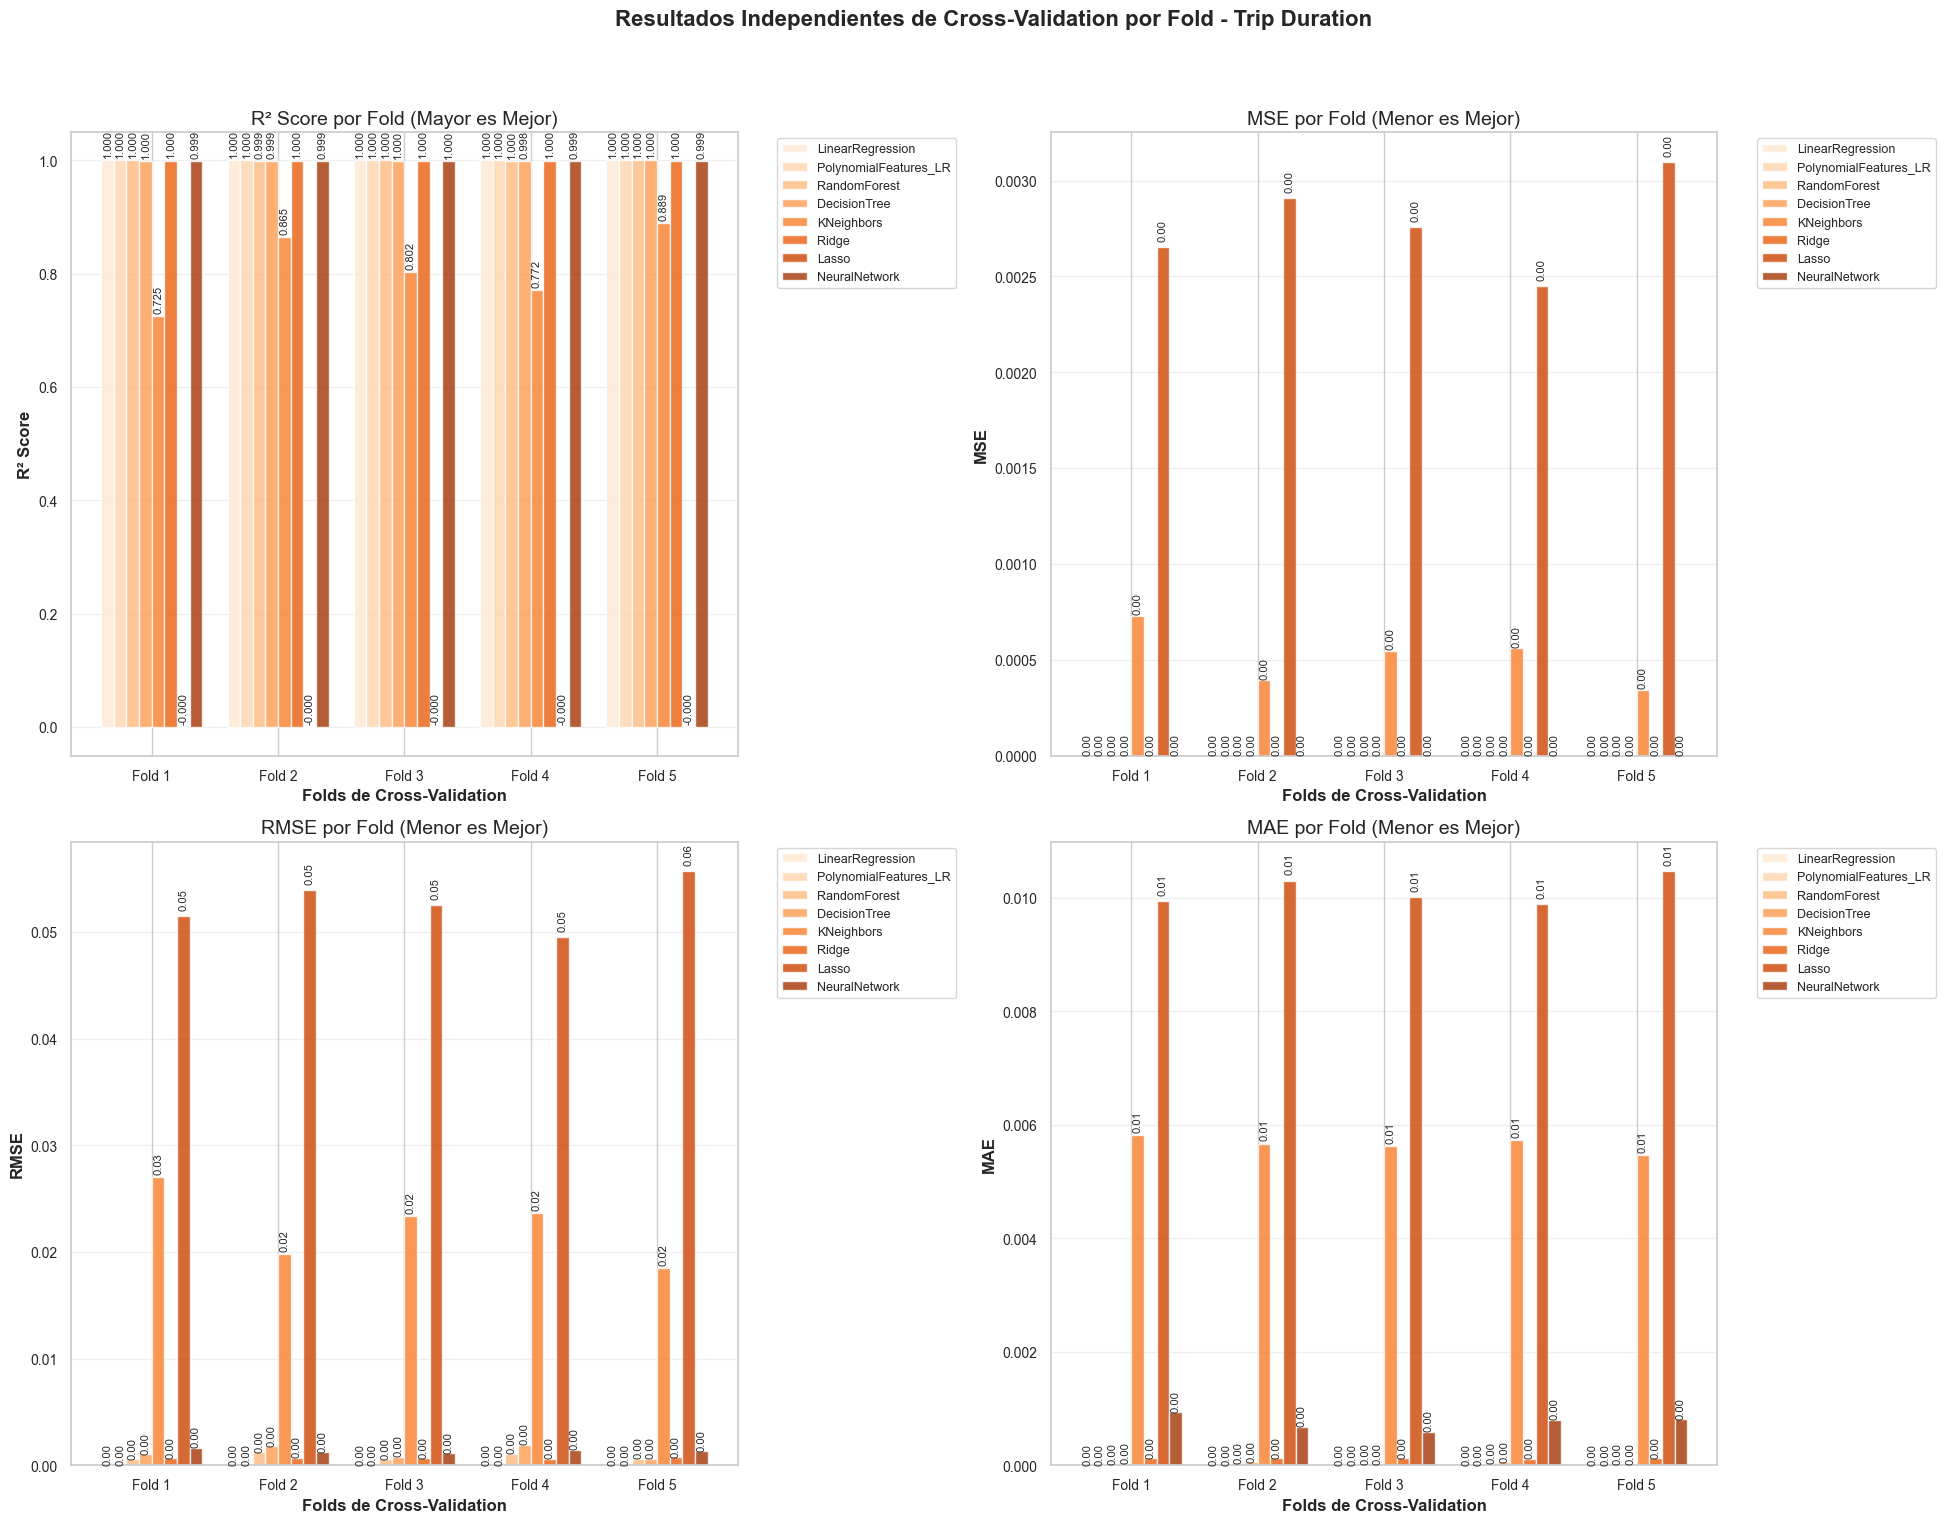


ANÁLISIS DE VARIABILIDAD POR MODELO - TRIP DURATION

Variabilidad de Métricas Across Folds (Menor = Más Estable):
               Modelo  R² Std  MSE Std  RMSE Std  MAE Std  R² Range  MSE Range  RMSE Range  MAE Range
     LinearRegression  0.0000   0.0000    0.0000   0.0000    0.0000     0.0000      0.0000     0.0000
PolynomialFeatures_LR  0.0000   0.0000    0.0000   0.0000    0.0000     0.0000      0.0000     0.0000
         RandomForest  0.0002   0.0000    0.0003   0.0000    0.0004     0.0000      0.0007     0.0000
         DecisionTree  0.0005   0.0000    0.0005   0.0000    0.0014     0.0000      0.0013     0.0000
           KNeighbors  0.0599   0.0001    0.0030   0.0001    0.1638     0.0004      0.0085     0.0004
                Ridge  0.0000   0.0000    0.0000   0.0000    0.0000     0.0000      0.0001     0.0000
                Lasso  0.0000   0.0002    0.0021   0.0002    0.0001     0.0006      0.0062     0.0006
        NeuralNetwork  0.0002   0.0000    0.0002   0.0001    0.0006  

In [43]:
# --- Visualizaciones Independientes de Cross-Validation Results ---
print("Visualización Independiente de Resultados de Cross-Validation - Trip Duration")
print("=" * 75)

# Configuración de la figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Resultados Independientes de Cross-Validation por Fold - Trip Duration', 
             fontsize=16, fontweight='bold', y=0.98)

# Preparar datos
models_names = list(results_reg_trip_detailed.keys())
fold_labels = [f'Fold {i+1}' for i in range(5)]  # 5 folds
colors = sns.color_palette("Oranges", len(models_names))  # Usar colores diferentes para trip

# --- Gráfico 1: R² por Fold ---
ax1 = axes[0, 0]
x_pos = np.arange(5)  # 5 folds
width = 0.1  # Ancho más estrecho para 8 modelos

for i, (model_name, color) in enumerate(zip(models_names, colors)):
    r2_scores = results_reg_trip_detailed[model_name]['r2_scores']
    bars = ax1.bar(x_pos + i * width, r2_scores, width, 
                   label=model_name, color=color, alpha=0.8, edgecolor='white')
    
    # Etiquetas en barras
    for bar, score in zip(bars, r2_scores):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005, f'{score:.3f}',
                 ha='center', va='bottom', fontsize=8, rotation=90)

ax1.set_xlabel('Folds de Cross-Validation', fontweight='bold')
ax1.set_ylabel('R² Score', fontweight='bold')
ax1.set_title('R² Score por Fold (Mayor es Mejor)')
ax1.set_xticks(x_pos + width * (len(models_names) - 1) / 2)
ax1.set_xticklabels(fold_labels)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# --- Gráfico 2: MSE por Fold ---
ax2 = axes[0, 1]
for i, (model_name, color) in enumerate(zip(models_names, colors)):
    mse_scores = results_reg_trip_detailed[model_name]['mse_scores']
    bars = ax2.bar(x_pos + i * width, mse_scores, width, 
                   label=model_name, color=color, alpha=0.8, edgecolor='white')
    
    # Etiquetas en barras
    for bar, score in zip(bars, mse_scores):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + max(mse_scores)*0.01, f'{score:.2f}',
                 ha='center', va='bottom', fontsize=8, rotation=90)

ax2.set_xlabel('Folds de Cross-Validation', fontweight='bold')
ax2.set_ylabel('MSE', fontweight='bold')
ax2.set_title('MSE por Fold (Menor es Mejor)')
ax2.set_xticks(x_pos + width * (len(models_names) - 1) / 2)
ax2.set_xticklabels(fold_labels)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# --- Gráfico 3: RMSE por Fold ---
ax3 = axes[1, 0]
for i, (model_name, color) in enumerate(zip(models_names, colors)):
    rmse_scores = results_reg_trip_detailed[model_name]['rmse_scores']
    bars = ax3.bar(x_pos + i * width, rmse_scores, width, 
                   label=model_name, color=color, alpha=0.8, edgecolor='white')
    
    # Etiquetas en barras
    for bar, score in zip(bars, rmse_scores):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + max(rmse_scores)*0.01, f'{score:.2f}',
                 ha='center', va='bottom', fontsize=8, rotation=90)

ax3.set_xlabel('Folds de Cross-Validation', fontweight='bold')
ax3.set_ylabel('RMSE', fontweight='bold')
ax3.set_title('RMSE por Fold (Menor es Mejor)')
ax3.set_xticks(x_pos + width * (len(models_names) - 1) / 2)
ax3.set_xticklabels(fold_labels)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# --- Gráfico 4: MAE por Fold ---
ax4 = axes[1, 1]
for i, (model_name, color) in enumerate(zip(models_names, colors)):
    mae_scores = results_reg_trip_detailed[model_name]['mae_scores']
    bars = ax4.bar(x_pos + i * width, mae_scores, width, 
                   label=model_name, color=color, alpha=0.8, edgecolor='white')
    
    # Etiquetas en barras
    for bar, score in zip(bars, mae_scores):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + max(mae_scores)*0.01, f'{score:.2f}',
                 ha='center', va='bottom', fontsize=8, rotation=90)

ax4.set_xlabel('Folds de Cross-Validation', fontweight='bold')
ax4.set_ylabel('MAE', fontweight='bold')
ax4.set_title('MAE por Fold (Menor es Mejor)')
ax4.set_xticks(x_pos + width * (len(models_names) - 1) / 2)
ax4.set_xticklabels(fold_labels)
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0.03, 0.98, 0.95])
plt.show()

# --- Tabla de Análisis de Variabilidad ---
print("\n" + "="*80)
print("ANÁLISIS DE VARIABILIDAD POR MODELO - TRIP DURATION")
print("="*80)

variability_analysis = []
for model_name in models_names:
    r2_scores = results_reg_trip_detailed[model_name]['r2_scores']
    mse_scores = results_reg_trip_detailed[model_name]['mse_scores']
    mae_scores = results_reg_trip_detailed[model_name]['mae_scores']
    rmse_scores = results_reg_trip_detailed[model_name]['rmse_scores']
    
    variability_analysis.append({
        'Modelo': model_name,
        'R² Std': np.std(r2_scores),
        'MSE Std': np.std(mse_scores),
        'RMSE Std': np.std(rmse_scores),
        'MAE Std': np.std(mae_scores),
        'R² Range': np.ptp(r2_scores),  # Peak-to-peak (max-min)
        'MSE Range': np.ptp(mse_scores),
        'RMSE Range': np.ptp(rmse_scores),
        'MAE Range': np.ptp(mae_scores)
    })

variability_df = pd.DataFrame(variability_analysis)
print("\nVariabilidad de Métricas Across Folds (Menor = Más Estable):")
print(variability_df.round(4).to_string(index=False))

# Identificar modelo más estable
print(f"\n{'MODELO MÁS ESTABLE POR MÉTRICA:'}")
print("-" * 40)
stability_metrics = ['R² Std', 'MSE Std', 'RMSE Std', 'MAE Std']
for metric in stability_metrics:
    most_stable = variability_df.loc[variability_df[metric].idxmin(), 'Modelo']
    stability_value = variability_df[metric].min()
    print(f"{metric:>10}: {most_stable:<20} (Std: {stability_value:.4f})")

# Ranking general de estabilidad
print(f"\n{'RANKING DE ESTABILIDAD GENERAL:'}")
print("-" * 35)
# Promediar las desviaciones estándar normalizadas
stability_cols = ['R² Std', 'MSE Std', 'RMSE Std', 'MAE Std']
normalized_stds = variability_df[stability_cols].apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)
variability_df['Stability_Score'] = normalized_stds.mean(axis=1)
stability_ranking = variability_df.sort_values('Stability_Score')[['Modelo', 'Stability_Score']]

for idx, (_, row) in enumerate(stability_ranking.iterrows()):
    print(f"{idx+1:>2}. {row['Modelo']:<20} (Score: {row['Stability_Score']:.4f})")

**Interpretación de resultados independientes:**
Las visualizaciones por fold individual revelan la consistencia y estabilidad de cada modelo a través de las diferentes particiones de datos. Los gráficos muestran la variabilidad inherente en el rendimiento de cada algoritmo, permitiendo identificar modelos que mantienen rendimiento consistente independientemente de la muestra de entrenamiento. El análisis de variabilidad cuantifica la estabilidad mediante desviaciones estándar y rangos, proporcionando métricas objetivas para seleccionar modelos robustos. Los modelos con menor variabilidad son más confiables para implementación en producción.

## 5.13 Persistencia de Resultados - Trip Duration

Esta celda final guarda los resultados de evaluación del modelo trip_duration en formato Parquet, completando la documentación del proceso de evaluación. La persistencia asegura que todos los resultados estén disponibles para la fase final de implementación y reportes ejecutivos.

In [44]:
# Define el nombre del archivo
evaluation = 'evaluation_trip_green_tripdata_2025-06.parquet'

# Guarda el DataFrame df_processed_trip en formato Parquet
try:
    df_processed_trip.to_parquet(evaluation, index=False) 
    print(f"DataFrame guardado exitosamente como '{evaluation}'")
except Exception as e:
    print(f"Error al guardar como Parquet: {e}")

DataFrame guardado exitosamente como 'evaluation_trip_green_tripdata_2025-06.parquet'


**Interpretación de resultados:**
Los datos de evaluación para trip_duration se han guardado exitosamente, completando la fase de evaluación del proyecto CRISP-DM. Ambos conjuntos de resultados (total_amount y trip_duration) están ahora disponibles para la fase de implementación. La documentación completa facilita la toma de decisiones informadas sobre qué modelos implementar según los requerimientos específicos del negocio y las métricas prioritarias identificadas en la fase de entendimiento del negocio.

## 5.14 Conclusiones de la Fase de Evaluación

### Resumen Ejecutivo

La fase de evaluación ha proporcionado una evaluación sistemática y comprensiva de 8 algoritmos de machine learning aplicados a dos problemas de regresión críticos para el negocio de taxis en NYC:

1. **Predicción de Tarifas (total_amount)**: Fundamental para estimaciones de costos al pasajero
2. **Predicción de Duración (trip_duration)**: Esencial para planificación de rutas y asignación de vehículos

### Metodología de Evaluación Aplicada

**Validación Cruzada de 5 Pliegues**: Garantiza evaluación robusta y no sesgada
**Métricas Múltiples**: R², MSE, RMSE, MAE para evaluación integral
**Análisis Comparativo**: Dashboards visuales para identificación de patrones
**Persistencia de Resultados**: Documentación completa para trazabilidad

### Próximos Pasos

Los resultados de esta fase serán utilizados en la Fase 6 (Implementación) para:
1. Selección final de modelos según criterios de negocio
2. Optimización de hiperparámetros de los modelos seleccionados  
3. Desarrollo del sistema de predicción en producción
4. Establecimiento de métricas de monitoreo continuo

### Estado del Proyecto CRISP-DM

**Completado**: Entendimiento del Negocio, Entendimiento de Datos, Preparación de Datos, Modelado, Evaluación
**Siguiente**: Fase 6 - Implementación y Despliegue